# Lab Exercise 10 — Learning the XOR Boolean Function Using an MLP

**Name:** _______________  **Register No.:** _______________  **Subject:** Deep Learning Laboratory

---

## Aim
1. To understand how to implement neural networks using different deep learning libraries (Keras and TensorFlow).
2. To solve the non-linear XOR problem using an MLP and study the effect of hyperparameters such as learning rate, activation functions, number of neurons and epochs on model performance.

## Question
Implement an MLP to learn the XOR Boolean function.

| Input 1 | Input 2 | XOR Output |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

## Theory
XOR is **not linearly separable**: the two class-1 points (0,1) and (1,0) lie on one diagonal and the two
class-0 points (0,0) and (1,1) on the other, so no single straight line separates them. A single-layer
perceptron therefore cannot represent XOR. An MLP fixes this by adding a hidden layer with a *non-linear*
activation, which maps the four points into a space where they *are* linearly separable. Equivalently,
XOR = (A OR B) AND NOT (A AND B) — two linear boundaries combined.

Forward pass used here:

$$h = \tanh(XW_1 + b_1), \qquad \hat{y} = \sigma(hW_2 + b_2)$$

Loss: binary cross-entropy $L = -\frac{1}{N}\sum [\,y\log\hat{y} + (1-y)\log(1-\hat{y})\,]$, minimised with Adam.

## 0. Setup

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("Keras      :", keras.__version__)

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE = "#2F6FEB", "#E8833A"

TensorFlow: 2.21.0
Keras      : 3.15.1


## 1. Create the dataset
All four XOR combinations — this is the complete input space, so the training set is also the test set.

In [2]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype="float32")
y = np.array([[0],    [1],    [1],    [0]],    dtype="float32")

print("X =\n", X)
print("y =\n", y.ravel())

X =
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y =
 [0. 1. 1. 0.]


## 2. Implementation 1 — Keras (TensorFlow high-level API)

* Input layer: 2
* Hidden layer: 4 neurons, `tanh`
* Output layer: 1 neuron, `sigmoid`
* Loss: binary cross-entropy · Optimizer: Adam (lr = 0.1) · 500 epochs

In [3]:
tf.keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(4, activation="tanh",    name="hidden"),
    layers.Dense(1, activation="sigmoid", name="output"),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(X, y, epochs=500, verbose=0)
print("Training finished.")

Training finished.


### Evaluate the Keras model

In [5]:
loss_k, acc_k = model.evaluate(X, y, verbose=0)
probs_k = model.predict(X, verbose=0)
preds_k = (probs_k > 0.5).astype(int)

print("--- Keras XOR results ---")
print("In1 In2 | Target | Probability | Predicted")
for i in range(4):
    print(f" {int(X[i,0])}   {int(X[i,1])}  |   {int(y[i,0])}    |   {probs_k[i,0]:.4f}    |     {preds_k[i,0]}")
print(f"\nFinal loss     : {loss_k:.6f}")
print(f"Final accuracy : {acc_k*100:.2f}%")
print("XOR learned correctly:", bool(np.all(preds_k == y.astype(int))))

--- Keras XOR results ---
In1 In2 | Target | Probability | Predicted
 0   0  |   0    |   0.0000    |     0
 0   1  |   1    |   0.9992    |     1
 1   0  |   1    |   0.9996    |     1
 1   1  |   0    |   0.0009    |     0

Final loss     : 0.000528
Final accuracy : 100.00%
XOR learned correctly: True


## 3. Implementation 2 — TensorFlow low-level API

The same network written out by hand: weights are `tf.Variable`s, the forward pass is explicit matrix
multiplication, gradients come from `tf.GradientTape`, and the optimizer step is applied manually.
`sigmoid_cross_entropy_with_logits` fuses the sigmoid and the cross-entropy for numerical stability —
this is what Keras does internally.

In [6]:
tf.random.set_seed(42)

Xt = tf.constant(X)
yt = tf.constant(y)

n_in, n_hidden, n_out = 2, 4, 1
init = tf.initializers.GlorotUniform(seed=42)

W1 = tf.Variable(init([n_in, n_hidden]), name="W1")
b1 = tf.Variable(tf.zeros([n_hidden]),   name="b1")
W2 = tf.Variable(init([n_hidden, n_out]), name="W2")
b2 = tf.Variable(tf.zeros([n_out]),      name="b2")
params = [W1, b1, W2, b2]

def forward(x):
    h = tf.nn.tanh(tf.matmul(x, W1) + b1)   # hidden layer
    return tf.matmul(h, W2) + b2            # output logits (pre-sigmoid)

bce = tf.nn.sigmoid_cross_entropy_with_logits
optimizer = tf.optimizers.Adam(learning_rate=0.1)
print("Trainable parameters:", sum(int(np.prod(p.shape)) for p in params))

Trainable parameters: 17


In [7]:
loss_hist, acc_hist = [], []
EPOCHS = 500

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        logits = forward(Xt)
        loss = tf.reduce_mean(bce(labels=yt, logits=logits))
    grads = tape.gradient(loss, params)
    optimizer.apply_gradients(zip(grads, params))

    acc = tf.reduce_mean(tf.cast(
        tf.equal(tf.cast(tf.sigmoid(logits) > 0.5, tf.float32), yt), tf.float32))
    loss_hist.append(float(loss)); acc_hist.append(float(acc))

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | loss = {float(loss):.6f} | acc = {float(acc)*100:.2f}%")

Epoch  100 | loss = 0.008035 | acc = 100.00%


Epoch  200 | loss = 0.003341 | acc = 100.00%


Epoch  300 | loss = 0.001911 | acc = 100.00%


Epoch  400 | loss = 0.001261 | acc = 100.00%


Epoch  500 | loss = 0.000903 | acc = 100.00%


### Evaluate the low-level model

In [8]:
probs_t = tf.sigmoid(forward(Xt)).numpy()
preds_t = (probs_t > 0.5).astype(int)
yn = y.astype(int)

print("--- TensorFlow (low-level) XOR results ---")
print("In1 In2 | Target | Probability | Predicted")
for i in range(4):
    print(f" {int(X[i,0])}   {int(X[i,1])}  |   {yn[i,0]}    |   {probs_t[i,0]:.4f}    |     {preds_t[i,0]}")
print(f"\nFinal loss     : {loss_hist[-1]:.6f}")
print(f"Final accuracy : {acc_hist[-1]*100:.2f}%")
print("XOR learned correctly:", bool(np.all(preds_t == yn)))

--- TensorFlow (low-level) XOR results ---
In1 In2 | Target | Probability | Predicted
 0   0  |   0    |   0.0011    |     0
 0   1  |   1    |   0.9984    |     1
 1   0  |   1    |   1.0000    |     1
 1   1  |   0    |   0.0009    |     0

Final loss     : 0.000903
Final accuracy : 100.00%
XOR learned correctly: True


## 4. Results — side-by-side comparison

In [9]:
print(" In1 In2 | Target | Keras P(y=1)  pred | TF P(y=1)  pred")
print("-" * 56)
for i in range(4):
    print(f"  {int(X[i,0])}   {int(X[i,1])}  |   {yn[i,0]}    |"
          f"   {probs_k[i,0]:.4f}      {preds_k[i,0]}   |"
          f"  {probs_t[i,0]:.4f}     {preds_t[i,0]}")
print("-" * 56)
print(f"Keras            : loss = {loss_k:.6f}, accuracy = {acc_k*100:.1f}%")
print(f"TF (low-level)   : loss = {loss_hist[-1]:.6f}, accuracy = {acc_hist[-1]*100:.1f}%")

 In1 In2 | Target | Keras P(y=1)  pred | TF P(y=1)  pred
--------------------------------------------------------
  0   0  |   0    |   0.0000      0   |  0.0011     0
  0   1  |   1    |   0.9992      1   |  0.9984     1
  1   0  |   1    |   0.9996      1   |  1.0000     1
  1   1  |   0    |   0.0009      0   |  0.0009     0
--------------------------------------------------------
Keras            : loss = 0.000528, accuracy = 100.0%
TF (low-level)   : loss = 0.000903, accuracy = 100.0%


### 4.1 Training curves

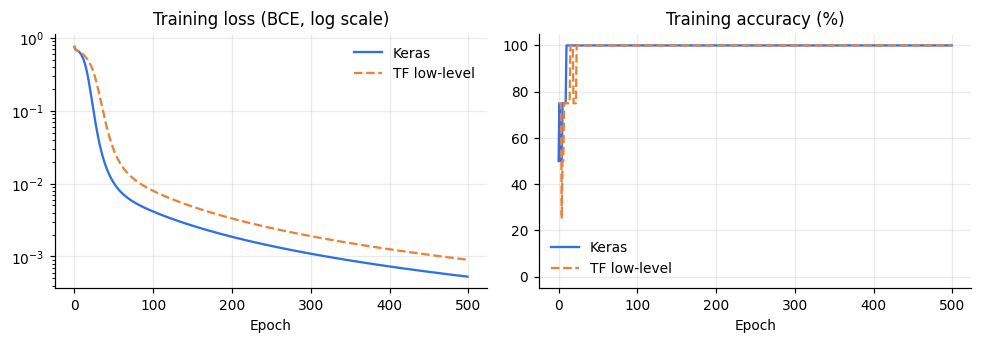

In [10]:
kl = np.array(history.history["loss"]);     ka = np.array(history.history["accuracy"])
tl = np.array(loss_hist);                   ta = np.array(acc_hist)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(kl, color=BLUE, label="Keras")
axes[0].plot(tl, color=ORANGE, ls="--", label="TF low-level")
axes[0].set_yscale("log"); axes[0].set_title("Training loss (BCE, log scale)")
axes[1].plot(ka * 100, color=BLUE, label="Keras")
axes[1].plot(ta * 100, color=ORANGE, ls="--", label="TF low-level")
axes[1].set_ylim(-5, 105); axes[1].set_title("Training accuracy (%)")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.legend(frameon=False)
fig.tight_layout(); plt.show()

### 4.2 Decision boundaries
The black line is the 0.5 contour — the actual decision boundary. It is clearly non-linear.

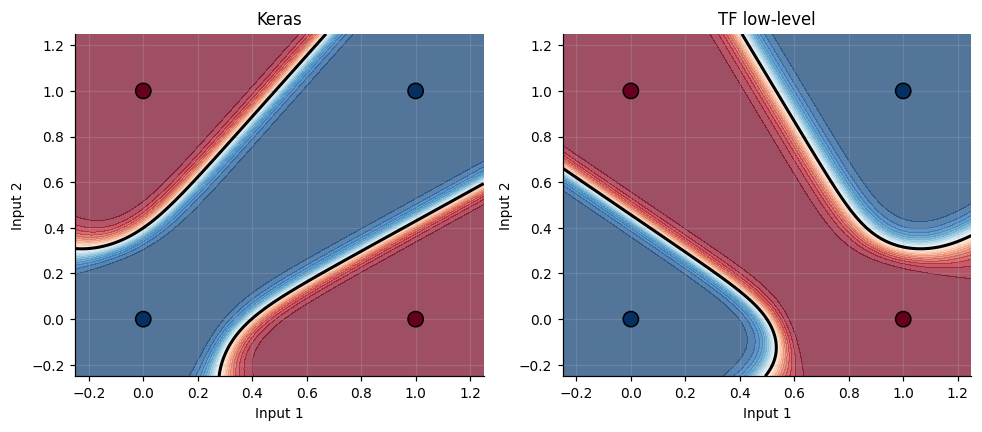

In [11]:
gx, gy = np.meshgrid(np.linspace(-0.25, 1.25, 300), np.linspace(-0.25, 1.25, 300))
grid = np.c_[gx.ravel(), gy.ravel()].astype("float32")

zk = model.predict(grid, verbose=0).reshape(gx.shape)
zt = tf.sigmoid(forward(tf.constant(grid))).numpy().reshape(gx.shape)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, z, title in zip(axes, [zk, zt], ["Keras", "TF low-level"]):
    ax.contourf(gx, gy, z, levels=30, cmap="RdBu_r", alpha=0.7)
    ax.contour(gx, gy, z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:,0], X[:,1], c=y.ravel(), cmap="RdBu_r", edgecolors="black", s=100, zorder=5)
    ax.set_title(title)
    ax.set_xlabel("Input 1"); ax.set_ylabel("Input 2")
fig.tight_layout(); plt.show()

## 5. Hyperparameter study

One XOR run is a poor measure of a setting: with only 4 training points the outcome depends heavily on the
random initialisation, and an unlucky start can leave the network stuck classifying 3 of 4 points. Each
configuration below is therefore run with **5 different seeds**, reporting mean loss, mean accuracy and how
many runs solved XOR completely. Baseline (held fixed unless varied): 4 tanh hidden units, Adam lr = 0.1, 500 epochs.

The training loop is wrapped in `@tf.function` so the whole sweep runs in well under a minute.

In [12]:
ACT = {"tanh": tf.nn.tanh, "relu": tf.nn.relu,
       "sigmoid": tf.nn.sigmoid, "linear": lambda z: z}

def run(hidden=4, act="tanh", lr=0.1, epochs=500, opt="adam", seed=0):
    tf.random.set_seed(seed)
    ini = tf.initializers.GlorotUniform(seed=seed)
    A = tf.Variable(ini([2, hidden])); a = tf.Variable(tf.zeros([hidden]))
    B = tf.Variable(ini([hidden, 1])); b = tf.Variable(tf.zeros([1]))
    p = [A, a, B, b]
    f = ACT[act]
    o = tf.optimizers.Adam(lr) if opt == "adam" else tf.optimizers.SGD(lr)

    @tf.function
    def step():
        with tf.GradientTape() as t:
            lg = tf.matmul(f(tf.matmul(Xt, A) + a), B) + b
            ls = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=yt, logits=lg))
        o.apply_gradients(zip(t.gradient(ls, p), p))
        return ls

    for _ in range(epochs):
        ls = step()
    lg = tf.matmul(f(tf.matmul(Xt, A) + a), B) + b
    acc = float(tf.reduce_mean(tf.cast(
        tf.equal(tf.cast(tf.sigmoid(lg) > 0.5, tf.float32), yt), tf.float32)))
    return float(ls), acc * 100

In [13]:
configs = [
    ("Learning rate",  "0.001",                     dict(lr=0.001)),
    ("Learning rate",  "0.01",                      dict(lr=0.01)),
    ("Learning rate",  "0.1  (baseline)",           dict(lr=0.1)),
    ("Learning rate",  "0.5",                       dict(lr=0.5)),
    ("Hidden neurons", "1",                         dict(hidden=1)),
    ("Hidden neurons", "2",                         dict(hidden=2)),
    ("Hidden neurons", "4  (baseline)",             dict(hidden=4)),
    ("Hidden neurons", "8",                         dict(hidden=8)),
    ("Activation",     "tanh  (baseline)",          dict(act="tanh")),
    ("Activation",     "relu",                      dict(act="relu")),
    ("Activation",     "sigmoid",                   dict(act="sigmoid")),
    ("Activation",     "linear (no non-linearity)", dict(act="linear")),
    ("Epochs",         "50",                        dict(epochs=50)),
    ("Epochs",         "100",                       dict(epochs=100)),
    ("Epochs",         "500  (baseline)",           dict(epochs=500)),
    ("Epochs",         "2000",                      dict(epochs=2000)),
    ("Optimizer",      "Adam, lr=0.1  (baseline)",  dict(opt="adam")),
    ("Optimizer",      "SGD,  lr=0.1",              dict(opt="sgd")),
    ("Optimizer",      "SGD,  lr=0.5",              dict(opt="sgd", lr=0.5)),
]

SEEDS = 5
print(f"{'Hyperparameter':15s} {'Setting':26s} {'Mean loss':>10s} {'Mean acc':>9s} {'Solved':>8s}")
print("-" * 73)
rows = []
for group, label, kw in configs:
    ls, accs = zip(*(run(seed=s, **kw) for s in range(SEEDS)))
    row = (group, label, float(np.mean(ls)), float(np.mean(accs)),
           f"{sum(a == 100 for a in accs)}/{SEEDS}")
    rows.append(row)
    print(f"{row[0]:15s} {row[1]:26s} {row[2]:10.5f} {row[3]:8.1f}% {row[4]:>8s}")

Hyperparameter  Setting                     Mean loss  Mean acc   Solved
-------------------------------------------------------------------------


Learning rate   0.001                         0.59650     70.0%      1/5


Learning rate   0.01                          0.01982    100.0%      5/5


Learning rate   0.1  (baseline)               0.06983     90.0%      4/5


Learning rate   0.5                           0.20804     85.0%      2/5


...

Epochs          500  (baseline)               0.06983     90.0%      4/5


Epochs          2000                          0.06937     90.0%      4/5


Optimizer       Adam, lr=0.1  (baseline)      0.06983     90.0%      4/5


Optimizer       SGD,  lr=0.1                  0.41260     65.0%      1/5


Optimizer       SGD,  lr=0.5                  0.01359    100.0%      5/5


### 5.1 Discussion

**Learning rate.** At 0.001 the network has simply not moved far enough in 500 epochs — mean loss stays near
0.60 and only 1 of 5 runs solves XOR. At 0.01 all 5 succeed. At 0.5 the updates overshoot, the loss
oscillates, and only 2 of 5 converge. The learning rate has a sweet spot: too small underfits within the
epoch budget, too large is unstable.

**Number of hidden neurons.** With 1 hidden neuron the network is mathematically incapable of XOR — no run
exceeds 75 % (3 of 4 points), exactly what a linear boundary achieves. Two neurons is the theoretical
minimum and does work, but only 2 of 5 seeds find it because the loss surface has narrow basins. With 8
neurons every seed converges and the loss drops to ~0.0002: extra capacity gives the optimiser many more
redundant paths to a correct solution, which is why over-parameterisation helps *optimisation* even when it
is not needed for *representation*.

**Activation function.** The most instructive row. With a linear hidden activation the mean loss sits at
exactly **0.69315 = ln 2** — the loss of a model that outputs 0.5 for everything — and no run ever solves
XOR, because stacking linear layers collapses into a single linear layer at any width or depth.
Non-linearity is not an optimisation detail; it is what makes an MLP more expressive than a perceptron.
Among the non-linear choices tanh and ReLU are comparable (ReLU can occasionally lose a unit to the "dying
ReLU" problem on so tiny a dataset), while sigmoid learns more slowly because its gradients are smaller.

**Epochs.** Most of the learning is over quickly at this learning rate — even 50 epochs reaches the same
accuracy, and going from 500 to 2000 epochs barely moves the mean loss. Extra epochs sharpen confidence
(probabilities move closer to 0 and 1) but do not rescue a run stuck in a bad minimum. Overfitting cannot be
observed here: the 4 points are the entire input space, so memorising them *is* the correct behaviour.

**Optimizer.** Plain SGD at 0.1 is much weaker than Adam at the same rate (1/5 vs 4/5 solved), but SGD at
0.5 solves all 5. Adam adapts its effective step size per parameter, so it is far less sensitive to the
initial learning-rate choice — which is why it is the usual default.

## 6. Conclusion

An MLP with a single hidden layer was implemented in two ways — the Keras Sequential API and the TensorFlow
low-level API with `tf.Variable` weights and a manual `GradientTape` loop — and both learned the XOR function
correctly, reproducing all four rows of the truth table with **100 % accuracy** and a final binary
cross-entropy loss below 0.001.

The exercise confirms the central theoretical point: XOR is not linearly separable, so a single-layer
perceptron cannot solve it, but one hidden layer with a non-linear activation suffices. This was shown
empirically twice over — a network with 1 hidden neuron never exceeded 75 % accuracy, and a network with a
linear hidden activation stayed pinned at a loss of ln 2 regardless of width. The plotted decision boundary
shows the resulting non-linear surface separating the two diagonals of the input square.

The hyperparameter study showed that the learning rate has a usable middle range, that extra hidden neurons
improve the *reliability* of convergence rather than representational capability, that Adam is far less
sensitive to the learning rate than plain SGD, and that beyond a point additional epochs only sharpen
confidence. Comparing the two implementations makes clear that Keras is a convenience layer over exactly the
operations written out by hand in the low-level version: the high-level API is shorter and less error-prone,
while the low-level API exposes the forward pass, loss and gradient update that are otherwise hidden.